## Prior Predictive Checks for AMPK Models

**Background (Linden-Santangeli, 2025):** Prior elicitation was performed for AMPK signaling models to ensure reasonable prior predictive densities. The process involved:
1. **Direct elicitation** using PreliZ's maximum entropy method to set LogNormal prior parameters with 90% of mass within literature-based bounds.
2. **Predictive elicitation** to iteratively refine priors so that prior predictive simulations exhibit the expected sigmoidal AMPK sensor response: near-zero initial activation, increasing activation rate, and full steady-state sensor activation.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import json, sys, os
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pytensor.link.jax.dispatch import jax_funcify
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

jax.config.update("jax_enable_x64", True)

sys.path.append("../")
from utils import solve_traj

sys.path.append("../models/")

savedir = '../../../results/param_est/prior_predictive/'
os.makedirs(savedir, exist_ok=True)

## Direct Prior Elicitation

In [2]:
# Direct prior elicitation from literature bounds using PreliZ maxent
# Fit LogNormal priors such that 90% of mass falls within param_bounds_original
models = ['MA_nonessential', 'MM_nonessential', 'MA_nonessential_phos', 'MM_nonessential_phos']
prob_mass = 0.9
maxent_priors = {}
for model_name in models:
    model_info_file = f'../models/{model_name}.json'
    with open(model_info_file, 'r') as file:
        info = json.load(file)

    bounds = info['param_bounds_original']
    priors = {}
    for param in info['params']:
        if len(bounds[param]) > 0:
            result = pz.maxent(pz.LogNormal(), lower=bounds[param][0],
                               upper=bounds[param][1], mass=prob_mass, plot=False)
            priors[param] = {'mu': float(result.mu), 'sigma': float(result.sigma)}
        else:
            priors[param] = {}
    maxent_priors[model_name] = priors
    print(f'{model_name}: elicited {sum(1 for v in priors.values() if v)} params with bounds')

/Users/judy/miniconda3/envs/ampkar/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/judy/miniconda3/envs/ampkar/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/judy/miniconda3/envs/ampkar/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/judy/miniconda3/envs/ampkar/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/judy/miniconda3/envs/ampkar/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/judy/miniconda3/envs/ampkar/

MA_nonessential: elicited 16 params with bounds
MM_nonessential: elicited 16 params with bounds
MA_nonessential_phos: elicited 17 params with bounds
MM_nonessential_phos: elicited 17 params with bounds


In [3]:
from MA_nonessential_diffrax import *
from MM_nonessential_diffrax import *
from MA_nonessential_phos_diffrax import *
from MM_nonessential_phos_diffrax import *

from pymc_jax_ode import SolOp, VJPSolOp

# ──────────────────────────────────────────────
# Model setup helper
# ──────────────────────────────────────────────
def load_model_info(json_path):
    info = json.load(open(json_path))
    state_names = list(info['init_conds'].keys())
    return {
        'info': info,
        'y0': list(info['init_conds'].values()),
        'ampkar_idxs': [state_names.index(s) for s in info['ampkar_states']],
        'pampkar_idxs': [state_names.index(s) for s in info['pampkar_states']],
    }

models_setup = {
    'MA': load_model_info('../models/MA_nonessential.json'),
    'MM': load_model_info('../models/MM_nonessential.json'),
    'MA_phos': load_model_info('../models/MA_nonessential_phos.json'),
    'MM_phos': load_model_info('../models/MM_nonessential_phos.json'),
}

# Metabolism parameters (same for all models)
metab = json.load(open('../models/metabolism_params_Coccimiglio.json'))
basal_params = list(metab['metab_params_basal'].values())
stress_params = list(metab['metab_params_stress'].values())

# ODE terms
ode_terms = {
    'MA': (dfrx.ODETerm(MA_nonessential(*basal_params)), dfrx.ODETerm(MA_nonessential(*stress_params))),
    'MM': (dfrx.ODETerm(MM_nonessential(*basal_params)), dfrx.ODETerm(MM_nonessential(*stress_params))),
    'MA_phos': (dfrx.ODETerm(MA_nonessential_phos(*basal_params)), dfrx.ODETerm(MA_nonessential_phos(*stress_params))),
    'MM_phos': (dfrx.ODETerm(MM_nonessential_phos(*basal_params)), dfrx.ODETerm(MM_nonessential_phos(*stress_params))),
}

# Load experimental data
def load_iono_data(filepath):
    npz = np.load(filepath)
    data = npz['mean'].reshape(1, -1)
    std = npz['std'].reshape(1, -1)
    times = npz['times']
    times_fine = np.linspace(times.min() * 60, times.max() * 60, num=1000)
    data_fine = np.interp(times_fine, times * 60, data[0]).reshape(1, -1)
    std_fine = np.interp(times_fine, times * 60, std[0]).reshape(1, -1)
    return {'times': times, 'data': data, 'std': std,
            'times_fine': times_fine, 'data_fine': data_fine, 'std_fine': std_fine}

datasets = {
    'wt':     {**load_iono_data('../../../AMPKARkey_data/HeLaAMPKAR3_260307_LKB1wt_Iono.npz'),   'label': 'WT Iono'},
    'lkb1kd': {**load_iono_data('../../../AMPKARkey_data/HeLaAMPKAR3_260307_LKB1kd_Iono.npz'),  'label': 'LKB1kd Iono'},
}

# Reference data for prior predictive checks
ref = datasets['wt']
iono_times = ref['times']
iono_times_fine = ref['times_fine']
iono_data_fine = ref['data_fine']
iono_std_fine = ref['std_fine']

# Solver parameters
atol, rtol = 1e-6, 1e-6
evnt_atol, evnt_rtol = 1e-12, 1e-12
pcoeff, icoeff = 0.3, 0.4
tmax_init = 1e3

# ──────────────────────────────────────────────
# Build simulator + PyTensor Op per model
# ──────────────────────────────────────────────
def make_sol_op(model_key):
    """Create a JIT simulator and PyTensor SolOp/VJPSolOp pair for a model.
    Uses unique subclasses so jax_funcify dispatch doesn't collide."""
    rhs_basal, rhs_stress = ode_terms[model_key]
    m = models_setup[model_key]
    y0, ai, pi = m['y0'], m['ampkar_idxs'], m['pampkar_idxs']

    @jax.jit
    def simulate(params):
        sol_stressed, _ = solve_traj(rhs_basal, rhs_stress, y0, params, iono_times_fine,
                                     tmax_init=tmax_init, rtol=rtol, atol=atol,
                                     evnt_atol=evnt_atol, evnt_rtol=evnt_rtol,
                                     pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)
        AMPKAR_tot = sol_stressed[jnp.array(ai), :].sum(axis=0)
        pAMPKAR = sol_stressed[jnp.array(pi), :].sum(axis=0)
        return jnp.reshape(pAMPKAR / AMPKAR_tot, (1, -1))

    def sol_op_jax(*params):
        return simulate(params)

    def vjp_sol_op_jax(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax, *params)
        return vjp_fn(gz)

    sol_op_jax_jitted = jax.jit(sol_op_jax)
    vjp_sol_op_jax_jitted = eqx.filter_jit(vjp_sol_op_jax)

    # Unique subclasses so jax_funcify dispatches correctly per model
    MySolOp = type(f'SolOp_{model_key}', (SolOp,), {})
    MyVJPSolOp = type(f'VJPSolOp_{model_key}', (VJPSolOp,), {})

    vjp_op = MyVJPSolOp(vjp_sol_op_jax_jitted)
    sol_op = MySolOp(sol_op_jax_jitted, vjp_op)

    @jax_funcify.register(MySolOp)
    def _(op, **kwargs):
        return sol_op_jax

    @jax_funcify.register(MyVJPSolOp)
    def _(op, **kwargs):
        return vjp_sol_op_jax

    return sol_op, simulate

sol_op_MA, simulate_MA = make_sol_op('MA')
sol_op_MM, simulate_MM = make_sol_op('MM')
sol_op_MA_phos, simulate_MA_phos = make_sol_op('MA_phos')
sol_op_MM_phos, simulate_MM_phos = make_sol_op('MM_phos')

# Convenience aliases used by downstream cells
model_info = models_setup['MA']['info']
sol_op = sol_op_MA

# Unpack for backward compat with cells that reference these directly
MA_info = models_setup['MA']['info']
MM_info = models_setup['MM']['info']
MA_phos_info = models_setup['MA_phos']['info']
MM_phos_info = models_setup['MM_phos']['info']
y0_MA = models_setup['MA']['y0']
y0_MM = models_setup['MM']['y0']
y0_MA_phos = models_setup['MA_phos']['y0']
y0_MM_phos = models_setup['MM_phos']['y0']
ampkar_idxs_MA = models_setup['MA']['ampkar_idxs']
pampkar_idxs_MA = models_setup['MA']['pampkar_idxs']
ampkar_idxs_MM = models_setup['MM']['ampkar_idxs']
pampkar_idxs_MM = models_setup['MM']['pampkar_idxs']
ampkar_idxs_MA_phos = models_setup['MA_phos']['ampkar_idxs']
pampkar_idxs_MA_phos = models_setup['MA_phos']['pampkar_idxs']
ampkar_idxs_MM_phos = models_setup['MM_phos']['ampkar_idxs']
pampkar_idxs_MM_phos = models_setup['MM_phos']['pampkar_idxs']

## Nonessential models (Model 3 and 4)

###  MA nonessential

The prior parameters below were obtained via predictive elicitation in Linden-Santangeli (2025). All free parameters use LogNormal priors; the nonessential activation parameters ($\alpha_{\rm LKB1}$, $\alpha_{\rm PP}$, $\beta_{\rm AMP}$) are truncated to enforce their mechanistic constraints ($\alpha_{\rm LKB1} < 1$, $\alpha_{\rm PP} > 1$, $\beta_{\rm AMP} > 1$).

In [4]:
prior_params = {
    'kOffAMP':    {'mu': -5,    'sigma': 1.5},
    'kOffADP':    {'mu': -3,    'sigma': 1.5},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kOffCaMKK':  {'mu': -1,    'sigma': 2},
    'kPhosCaMKK': {'mu': -3.5,  'sigma': 2},
    'kOffLKB1':   {'mu': -1,    'sigma': 2},
    'alphaLKB1':  {'mu': -3,    'sigma': 2.5},
    'kPhosLKB1':  {'mu': -3.5,  'sigma': 2},
    'kOffPP':     {'mu': -1,    'sigma': 1},
    'alphaPP':    {'mu': 2,     'sigma': 1},
    'kDephosPP':  {'mu': -7,    'sigma': 3},
    'kOffAMPK':   {'mu': 2.5,   'sigma': 1},
    'kPhosAMPK':  {'mu': -3,    'sigma': 1},
    'betaAMP':    {'mu': 2,     'sigma': 1},
    'kOffPP1':    {'mu': 0,     'sigma': 1},
    'kDephosPP1': {'mu': -15,   'sigma': 3},
}

std_mult = 0.001  # small likelihood std to isolate prior effect

def build_model(pp=prior_params, std_mult=std_mult):
    with pm.Model() as model:
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=pp['kOffAMP']['mu'], sigma=pp['kOffAMP']['sigma'])
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=pp['kOffADP']['mu'], sigma=pp['kOffADP']['sigma'])
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=pp['kOffATP']['mu'], sigma=pp['kOffATP']['sigma'])
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=pp['kOffCaMKK']['mu'], sigma=pp['kOffCaMKK']['sigma'])
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=pp['kPhosCaMKK']['mu'], sigma=pp['kPhosCaMKK']['sigma'])
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=pp['kOffLKB1']['mu'], sigma=pp['kOffLKB1']['sigma'])
        alphaLKB1_dist = pm.LogNormal.dist(mu=pp['alphaLKB1']['mu'], sigma=pp['alphaLKB1']['sigma'])
        alphaLKB1 = pm.Truncated('alphaLKB1', alphaLKB1_dist, upper=1.0)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=pp['kPhosLKB1']['mu'], sigma=pp['kPhosLKB1']['sigma'])
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=pp['kOffPP']['mu'], sigma=pp['kOffPP']['sigma'])
        alphaPP_dist = pm.LogNormal.dist(mu=pp['alphaPP']['mu'], sigma=pp['alphaPP']['sigma'])
        alphaPP = pm.Truncated('alphaPP', alphaPP_dist, lower=1.0)
        kDephosPP = pm.LogNormal('kDephosPP', mu=pp['kDephosPP']['mu'], sigma=pp['kDephosPP']['sigma'])
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=pp['kOffAMPK']['mu'], sigma=pp['kOffAMPK']['sigma'])
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=pp['kPhosAMPK']['mu'], sigma=pp['kPhosAMPK']['sigma'])
        betaAMP_dist = pm.LogNormal.dist(mu=pp['betaAMP']['mu'], sigma=pp['betaAMP']['sigma'])
        betaAMP = pm.Truncated('betaAMP', betaAMP_dist, lower=1.0)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=pp['kOffPP1']['mu'], sigma=pp['kOffPP1']['sigma'])
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=pp['kDephosPP1']['mu'], sigma=pp['kDephosPP1']['sigma'])

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK,
                  kPhosCaMKK, kOnLKB1, kOffLKB1, alphaLKB1, kPhosLKB1, kOnPP, kOffPP, alphaPP, kDephosPP,
                  kOnAMPK, kOffAMPK, kPhosAMPK, betaAMP, kOnPP1, kOffPP1, kDephosPP1]

        sim = pm.Deterministic('simulation', sol_op(*params))
        pm.Normal('like', mu=sim, sigma=iono_std_fine * std_mult, observed=iono_data_fine)

    return model

In [5]:
pm_model = build_model()
with pm_model:
    prior_pred = pm.sample_prior_predictive(samples=500)

Sampling: [alphaLKB1, alphaPP, betaAMP, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


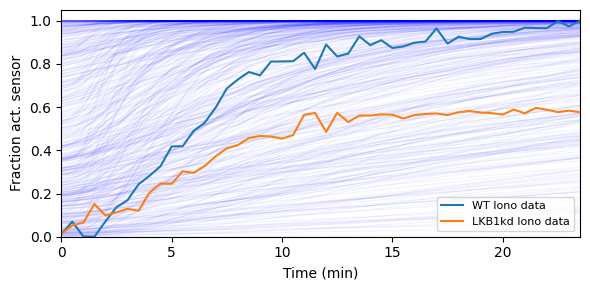

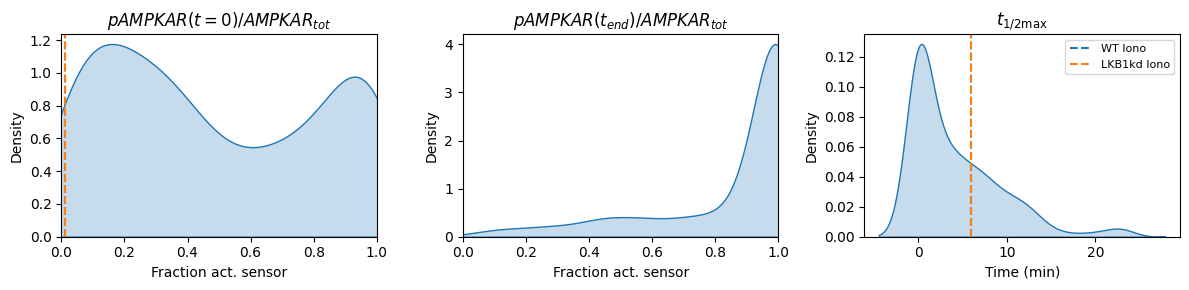

In [6]:
def compute_half_max(arr):
    half_max = arr.max() / 2
    return jnp.argmin(jnp.abs(arr - half_max))

colors = {'wt': 'tab:blue', 'lkb1kd': 'tab:orange'}
preds = np.squeeze(prior_pred.prior_predictive['like'].values[0])
if preds.ndim == 1:
    preds = preds[np.newaxis, :]

# --- Trajectories with both data traces overlaid ---
fig, ax = plt.subplots(figsize=(6, 3))
for i in range(preds.shape[0]):
    ax.plot(iono_times_fine / 60, preds[i], 'b', alpha=0.05, linewidth=0.75)
for key, ds in datasets.items():
    ax.plot(ds['times'], ds['data'].flatten(), markersize=3,
            color=colors[key], label=ds['label'] + ' data', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Fraction act. sensor')
ax.set_xlim([0, iono_times_fine.max() / 60])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential.pdf', bbox_inches='tight')

# --- Density statistics ---
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3))

# Initial activation
sns.kdeplot(preds[:, 0], ax=axes2[0], fill=True, alpha=0.25)
for key, ds in datasets.items():
    axes2[0].axvline(ds['data'].flatten()[0], color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[0].set_xlabel('Fraction act. sensor')
axes2[0].set_title(r'$pAMPKAR(t=0) / AMPKAR_{tot}$')
axes2[0].set_xlim([0, 1])

# Final activation
sns.kdeplot(preds[:, -1], ax=axes2[1], fill=True, alpha=0.25)
axes2[1].set_xlabel('Fraction act. sensor')
axes2[1].set_title(r'$pAMPKAR(t_{end}) / AMPKAR_{tot}$')
axes2[1].set_xlim([0, 1])

# Time to half-max
t_halfs_idxs = jnp.apply_along_axis(compute_half_max, 1, preds)
t_halfs = [iono_times_fine[i] / 60 for i in t_halfs_idxs]
sns.kdeplot(t_halfs, ax=axes2[2], fill=True, alpha=0.25)
for key, ds in datasets.items():
    t_half_data = ds['times'][compute_half_max(ds['data'].flatten())]
    axes2[2].axvline(t_half_data, color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[2].set_xlabel('Time (min)')
axes2[2].set_title(r'$t_{1/2 \max}$')
axes2[2].legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(savedir + 'prior_pred_MA_nonessential_stats.pdf', bbox_inches='tight')

In [12]:
# Compute 95% HDI bounds for GSA sampling and save updated model info
bounds_updated = {}
prior_params_updated = {}
for param in model_info['params']:
    if param in prior_params:
        bounds_updated[param] = list(
            pz.LogNormal(mu=prior_params[param]['mu'], sigma=prior_params[param]['sigma'])
            .hdi(0.95, fmt='.8f')
        )
        prior_params_updated[param] = prior_params[param]
    else:
        bounds_updated[param] = []
        prior_params_updated[param] = {}

model_info['param_bounds'] = bounds_updated
model_info['prior_params'] = prior_params_updated

with open('../models/MA_nonessential.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print('Saved updated model info to MA_nonessential.json')

Saved updated model info to MA_nonessential.json


### MM nonessential

The MM nonessential model uses Michaelis-Menten kinetics (14 states) instead of explicit enzyme binding (33 states for MA). Key parameter differences:
- MM uses lumped `kCaMKK`/`KmCaMKK` + `CaMKKtot` instead of MA's `kOnCaMKK`/`kOffCaMKK`/`kPhosCaMKK`
- Same pattern for LKB1, PP, PP1, and AMPK phosphorylation
- `kAMPK`, `KmAMPK`, `kPP1`, `KmPP1` and enzyme totals (`CaMKKtot`, `LKB1tot`, `PPtot`, `PP1tot`) are fixed at nominal values

We start with the priors from the original Linden-Santangeli (2025) elicitation and verify they produce reasonable prior predictive densities with HeLa AMPKAR data.

In [13]:
prior_params_MM = {
    'kOffAMP':    {'mu': -5.5,    'sigma': 1},
    'kOffADP':    {'mu': -5.5,  'sigma': 1},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kCaMKK':     {'mu': -3,    'sigma': 1},
    'KmCaMKK':    {'mu': 0,     'sigma': 1},
    'kLKB1':      {'mu': -3,    'sigma': 1},
    'KmLKB1':     {'mu': 5,     'sigma': 1},
    'alphaLKB1':  {'mu': 0,     'sigma': 3},
    'kPP':        {'mu': -2,    'sigma': 1},
    'KmPP':       {'mu': 1,     'sigma': 3},
    'alphaPP':    {'mu': 1.5,   'sigma': 1.5},
    'betaAMP':    {'mu': 1.5,   'sigma': 1.5},
}

def build_model_MM(pp=prior_params_MM, std_mult=0.001):
    with pm.Model() as model_MM:
        # AXP binding — kOn fixed at 1.0, kOff sampled
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=pp['kOffAMP']['mu'], sigma=pp['kOffAMP']['sigma'])
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=pp['kOffADP']['mu'], sigma=pp['kOffADP']['sigma'])
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=pp['kOffATP']['mu'], sigma=pp['kOffATP']['sigma'])
        # CaMKK — MM kinetics
        kCaMKK = pm.LogNormal('kCaMKK', mu=pp['kCaMKK']['mu'], sigma=pp['kCaMKK']['sigma'])
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=pp['KmCaMKK']['mu'], sigma=pp['KmCaMKK']['sigma'])
        # LKB1 — MM kinetics
        kLKB1 = pm.LogNormal('kLKB1', mu=pp['kLKB1']['mu'], sigma=pp['kLKB1']['sigma'])
        KmLKB1 = pm.LogNormal('KmLKB1', mu=pp['KmLKB1']['mu'], sigma=pp['KmLKB1']['sigma'])
        alphaLKB1_dist = pm.LogNormal.dist(mu=pp['alphaLKB1']['mu'], sigma=pp['alphaLKB1']['sigma'])
        alphaLKB1 = pm.Truncated('alphaLKB1', alphaLKB1_dist, upper=1.0)
        # PP — MM kinetics
        kPP = pm.LogNormal('kPP', mu=pp['kPP']['mu'], sigma=pp['kPP']['sigma'])
        KmPP = pm.LogNormal('KmPP', mu=pp['KmPP']['mu'], sigma=pp['KmPP']['sigma'])
        alphaPP_dist = pm.LogNormal.dist(mu=pp['alphaPP']['mu'], sigma=pp['alphaPP']['sigma'])
        alphaPP = pm.Truncated('alphaPP', alphaPP_dist, lower=1.0)
        # AMPK phosphorylation — fixed at nominal
        kAMPK = pm.Data('kAMPK', MM_info['nominal_params']['kAMPK'])
        KmAMPK = pm.Data('KmAMPK', MM_info['nominal_params']['KmAMPK'])
        betaAMP_dist = pm.LogNormal.dist(mu=pp['betaAMP']['mu'], sigma=pp['betaAMP']['sigma'])
        betaAMP = pm.Truncated('betaAMP', betaAMP_dist, lower=1.0)
        # PP1 — fixed at nominal
        kPP1 = pm.Data('kPP1', MM_info['nominal_params']['kPP1'])
        KmPP1 = pm.Data('KmPP1', MM_info['nominal_params']['KmPP1'])
        # Enzyme totals — fixed
        CaMKKtot = pm.Data('CaMKKtot', 1.0)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)

        # Parameter order must match MM_nonessential.json "params" list
        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP,
                  kCaMKK, KmCaMKK, kLKB1, KmLKB1, alphaLKB1, kPP, KmPP, alphaPP,
                  kAMPK, KmAMPK, betaAMP, kPP1, KmPP1, CaMKKtot, LKB1tot, PPtot, PP1tot]

        sim = pm.Deterministic('simulation', sol_op_MM(*params))
        pm.Normal('like', mu=sim, sigma=iono_std_fine * std_mult, observed=iono_data_fine)

    return model_MM

In [14]:
pm_model_MM = build_model_MM()
with pm_model_MM:
    prior_pred_MM = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, alphaLKB1, alphaPP, betaAMP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


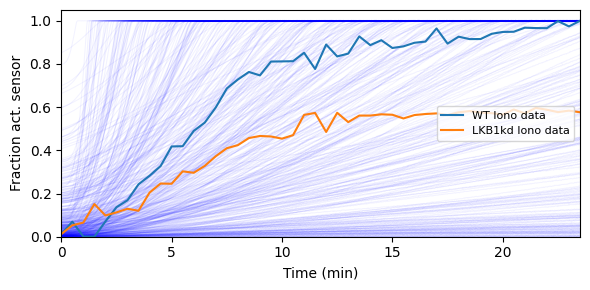

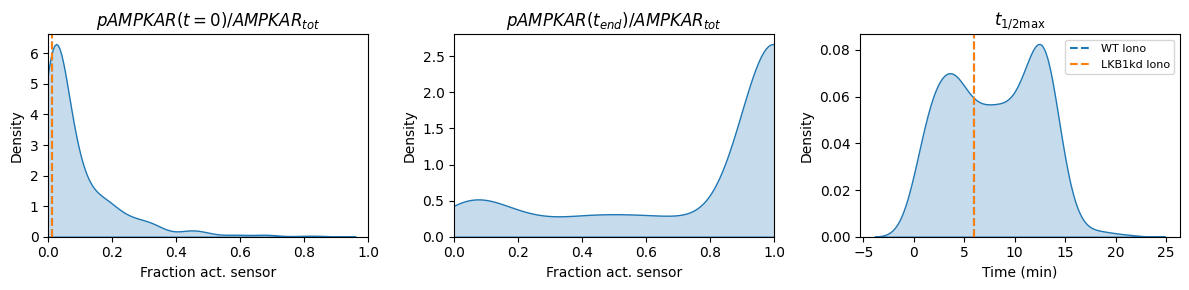

In [15]:
colors = {'wt': 'tab:blue', 'lkb1kd': 'tab:orange'}

def compute_half_max(arr):
    half_max = arr.max() / 2
    return jnp.argmin(jnp.abs(arr - half_max))

preds_MM = np.squeeze(prior_pred_MM.prior_predictive['like'].values[0])
if preds_MM.ndim == 1:
    preds_MM = preds_MM[np.newaxis, :]

# --- Trajectories with both data traces overlaid ---
fig, ax = plt.subplots(figsize=(6, 3))
for i in range(preds_MM.shape[0]):
    ax.plot(iono_times_fine / 60, preds_MM[i], 'b', alpha=0.05, linewidth=0.75)
for key, ds in datasets.items():
    ax.plot(ds['times'], ds['data'].flatten(), markersize=3,
            color=colors[key], label=ds['label'] + ' data', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Fraction act. sensor')
ax.set_xlim([0, iono_times_fine.max() / 60])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MM_nonessential.pdf', bbox_inches='tight')

# --- Density statistics ---
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3))

# Initial activation
sns.kdeplot(preds_MM[:, 0], ax=axes2[0], fill=True, alpha=0.25)
for key, ds in datasets.items():
    axes2[0].axvline(ds['data'].flatten()[0], color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[0].set_xlabel('Fraction act. sensor')
axes2[0].set_title(r'$pAMPKAR(t=0) / AMPKAR_{tot}$')
axes2[0].set_xlim([0, 1])

# Final activation
sns.kdeplot(preds_MM[:, -1], ax=axes2[1], fill=True, alpha=0.25)
axes2[1].set_xlabel('Fraction act. sensor')
axes2[1].set_title(r'$pAMPKAR(t_{end}) / AMPKAR_{tot}$')
axes2[1].set_xlim([0, 1])

# Time to half-max
t_halfs_idxs_MM = jnp.apply_along_axis(compute_half_max, 1, preds_MM)
t_halfs_MM = [iono_times_fine[i] / 60 for i in t_halfs_idxs_MM]
sns.kdeplot(t_halfs_MM, ax=axes2[2], fill=True, alpha=0.25)
for key, ds in datasets.items():
    t_half_data = ds['times'][compute_half_max(ds['data'].flatten())]
    axes2[2].axvline(t_half_data, color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[2].set_xlabel('Time (min)')
axes2[2].set_title(r'$t_{1/2 \max}$')
axes2[2].legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(savedir + 'prior_pred_MM_nonessential_stats.pdf', bbox_inches='tight')

In [16]:
# Compute 95% HDI bounds and save updated MM nonessential model info
MM_bounds_updated = {}
MM_prior_params_updated = {}
for param in MM_info['params']:
    if param in prior_params_MM:
        MM_bounds_updated[param] = list(
            pz.LogNormal(mu=prior_params_MM[param]['mu'], sigma=prior_params_MM[param]['sigma'])
            .hdi(0.95, fmt='.8f')
        )
        MM_prior_params_updated[param] = prior_params_MM[param]
    else:
        MM_bounds_updated[param] = []
        MM_prior_params_updated[param] = {}

MM_info['param_bounds'] = MM_bounds_updated
MM_info['prior_params'] = MM_prior_params_updated

with open('../models/MM_nonessential.json', 'w') as f:
    json.dump(MM_info, f, indent=4)
print('Saved updated model info to MM_nonessential.json')

Saved updated model info to MM_nonessential.json


## Nonessential models (Model 5 and 6)

### MA nonessential phos

Model 5 replaces alpha parameters on dissociation rates with beta parameters on catalytic rates:
- $\beta_{\rm LKB1} > 1$: AMP/ADP **increase** LKB1 phosphorylation rate (replaces $\alpha_{\rm LKB1} < 1$ on dissociation)
- $\beta_{\rm CaMKK} > 1$: AMP/ADP **increase** CaMKK phosphorylation rate (new — not present in Model 3)
- $\beta_{\rm PP} < 1$: AMP/ADP **decrease** PP dephosphorylation rate (replaces $\alpha_{\rm PP} > 1$ on dissociation)
- $\beta_{\rm AMP} > 1$: allosteric activation of AMPKAR phosphorylation (unchanged from Model 3)

The shared kinetic parameters (kOff, kPhos, kDephos rates) retain the same priors as the alpha MA model. The beta parameters use LogNormal priors with truncation to enforce their mechanistic direction.

In [17]:
prior_params_MA_phos = {
    'kOffAMP':    {'mu': -5,    'sigma': 1.5},
    'kOffADP':    {'mu': -3,    'sigma': 1.5},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kOffCaMKK':  {'mu': -1,    'sigma': 2},
    'kPhosCaMKK': {'mu': -3.5,  'sigma': 2},
    'betaCaMKK':  {'mu': 3,     'sigma': 2.5},     # > 1; AMP/ADP enhance CaMKK catalysis
    'kOffLKB1':   {'mu': -1,    'sigma': 2},
    'betaLKB1':   {'mu': 3,     'sigma': 2.5},     # > 1; AMP/ADP enhance LKB1 catalysis
    'kPhosLKB1':  {'mu': -3.5,  'sigma': 2},
    'kOffPP':     {'mu': -1,    'sigma': 1},
    'betaPP':     {'mu': -2,    'sigma': 1},     # < 1; AMP/ADP reduce PP catalysis
    'kDephosPP':  {'mu': -7,    'sigma': 3},
    'kOffAMPK':   {'mu': 2.5,   'sigma': 1},
    'kPhosAMPK':  {'mu': -3,    'sigma': 1},
    'betaAMP':    {'mu': 2,     'sigma': 1},
    'kOffPP1':    {'mu': 0,     'sigma': 1},
    'kDephosPP1': {'mu': -13,   'sigma': 5},
}

std_mult_phos = 0.001

def build_model_MA_phos(pp=prior_params_MA_phos, std_mult=std_mult_phos):
    with pm.Model() as model_phos:
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=pp['kOffAMP']['mu'], sigma=pp['kOffAMP']['sigma'])
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=pp['kOffADP']['mu'], sigma=pp['kOffADP']['sigma'])
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=pp['kOffATP']['mu'], sigma=pp['kOffATP']['sigma'])
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=pp['kOffCaMKK']['mu'], sigma=pp['kOffCaMKK']['sigma'])
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=pp['kPhosCaMKK']['mu'], sigma=pp['kPhosCaMKK']['sigma'])
        betaCaMKK_dist = pm.LogNormal.dist(mu=pp['betaCaMKK']['mu'], sigma=pp['betaCaMKK']['sigma'])
        betaCaMKK = pm.Truncated('betaCaMKK', betaCaMKK_dist, lower=1.0)
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=pp['kOffLKB1']['mu'], sigma=pp['kOffLKB1']['sigma'])
        betaLKB1_dist = pm.LogNormal.dist(mu=pp['betaLKB1']['mu'], sigma=pp['betaLKB1']['sigma'])
        betaLKB1 = pm.Truncated('betaLKB1', betaLKB1_dist, lower=1.0)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=pp['kPhosLKB1']['mu'], sigma=pp['kPhosLKB1']['sigma'])
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=pp['kOffPP']['mu'], sigma=pp['kOffPP']['sigma'])
        betaPP_dist = pm.LogNormal.dist(mu=pp['betaPP']['mu'], sigma=pp['betaPP']['sigma'])
        betaPP = pm.Truncated('betaPP', betaPP_dist, upper=1.0)
        kDephosPP = pm.LogNormal('kDephosPP', mu=pp['kDephosPP']['mu'], sigma=pp['kDephosPP']['sigma'])
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=pp['kOffAMPK']['mu'], sigma=pp['kOffAMPK']['sigma'])
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=pp['kPhosAMPK']['mu'], sigma=pp['kPhosAMPK']['sigma'])
        betaAMP_dist = pm.LogNormal.dist(mu=pp['betaAMP']['mu'], sigma=pp['betaAMP']['sigma'])
        betaAMP = pm.Truncated('betaAMP', betaAMP_dist, lower=1.0)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=pp['kOffPP1']['mu'], sigma=pp['kOffPP1']['sigma'])
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=pp['kDephosPP1']['mu'], sigma=pp['kDephosPP1']['sigma'])

        # Parameter order must match MA_nonessential_phos.json "params" list (25 params)
        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK,
                  kPhosCaMKK, betaCaMKK, kOnLKB1, kOffLKB1, betaLKB1, kPhosLKB1, kOnPP, kOffPP,
                  betaPP, kDephosPP, kOnAMPK, kOffAMPK, kPhosAMPK, betaAMP, kOnPP1, kOffPP1, kDephosPP1]

        sim = pm.Deterministic('simulation', sol_op_MA_phos(*params))
        pm.Normal('like', mu=sim, sigma=iono_std_fine * std_mult, observed=iono_data_fine)

    return model_phos

In [18]:
pm_model_MA_phos = build_model_MA_phos()
with pm_model_MA_phos:
    prior_pred_MA_phos = pm.sample_prior_predictive(samples=500)

Sampling: [betaAMP, betaCaMKK, betaLKB1, betaPP, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


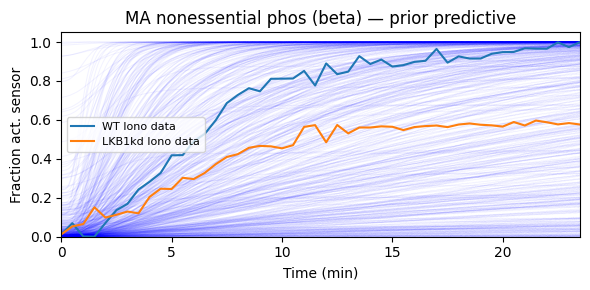

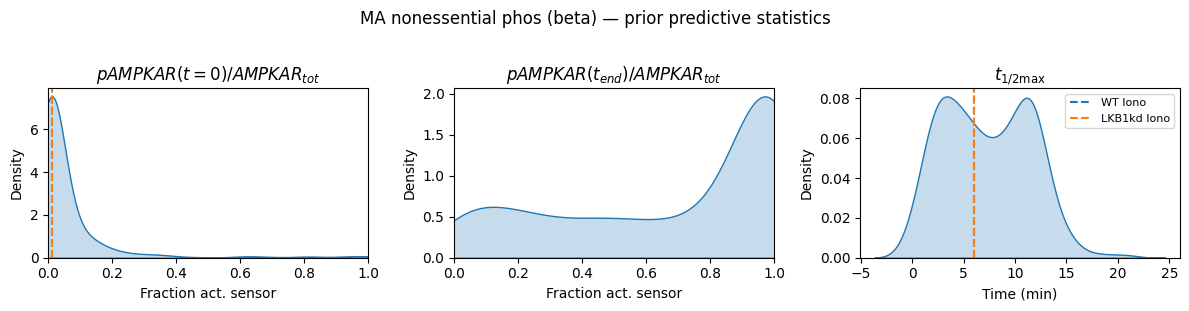

In [19]:
colors = {'wt': 'tab:blue', 'lkb1kd': 'tab:orange'}

def compute_half_max(arr):
    half_max = arr.max() / 2
    return jnp.argmin(jnp.abs(arr - half_max))

preds_MA_phos = np.squeeze(prior_pred_MA_phos.prior_predictive['like'].values[0])
if preds_MA_phos.ndim == 1:
    preds_MA_phos = preds_MA_phos[np.newaxis, :]

# --- Trajectories with both data traces overlaid ---
fig, ax = plt.subplots(figsize=(6, 3))
for i in range(preds_MA_phos.shape[0]):
    ax.plot(iono_times_fine / 60, preds_MA_phos[i], 'b', alpha=0.05, linewidth=0.75)
for key, ds in datasets.items():
    ax.plot(ds['times'], ds['data'].flatten(), markersize=3,
            color=colors[key], label=ds['label'] + ' data', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Fraction act. sensor')
ax.set_xlim([0, iono_times_fine.max() / 60])
ax.set_ylim([0, 1.05])
ax.set_title('MA nonessential phos (beta) — prior predictive')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential_phos.pdf', bbox_inches='tight')

# --- Density statistics ---
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3))

# Initial activation
sns.kdeplot(preds_MA_phos[:, 0], ax=axes2[0], fill=True, alpha=0.25)
for key, ds in datasets.items():
    axes2[0].axvline(ds['data'].flatten()[0], color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[0].set_xlabel('Fraction act. sensor')
axes2[0].set_title(r'$pAMPKAR(t=0) / AMPKAR_{tot}$')
axes2[0].set_xlim([0, 1])

# Final activation
sns.kdeplot(preds_MA_phos[:, -1], ax=axes2[1], fill=True, alpha=0.25)
axes2[1].set_xlabel('Fraction act. sensor')
axes2[1].set_title(r'$pAMPKAR(t_{end}) / AMPKAR_{tot}$')
axes2[1].set_xlim([0, 1])

# Time to half-max
t_halfs_idxs_phos = jnp.apply_along_axis(compute_half_max, 1, preds_MA_phos)
t_halfs_phos = [iono_times_fine[i] / 60 for i in t_halfs_idxs_phos]
sns.kdeplot(t_halfs_phos, ax=axes2[2], fill=True, alpha=0.25)
for key, ds in datasets.items():
    t_half_data = ds['times'][compute_half_max(ds['data'].flatten())]
    axes2[2].axvline(t_half_data, color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[2].set_xlabel('Time (min)')
axes2[2].set_title(r'$t_{1/2 \max}$')
axes2[2].legend(fontsize=8)

fig2.suptitle('MA nonessential phos (beta) — prior predictive statistics', y=1.02)
fig2.tight_layout()
fig2.savefig(savedir + 'prior_pred_MA_nonessential_phos_stats.pdf', bbox_inches='tight')

In [20]:
# Compute 95% HDI bounds and save updated MA nonessential phos model info
MA_phos_bounds_updated = {}
MA_phos_prior_params_updated = {}
for param in MA_phos_info['params']:
    if param in prior_params_MA_phos:
        MA_phos_bounds_updated[param] = list(
            pz.LogNormal(mu=prior_params_MA_phos[param]['mu'], sigma=prior_params_MA_phos[param]['sigma'])
            .hdi(0.95, fmt='.8f')
        )
        MA_phos_prior_params_updated[param] = prior_params_MA_phos[param]
    else:
        MA_phos_bounds_updated[param] = []
        MA_phos_prior_params_updated[param] = {}

MA_phos_info['param_bounds'] = MA_phos_bounds_updated
MA_phos_info['prior_params'] = MA_phos_prior_params_updated

with open('../models/MA_nonessential_phos.json', 'w') as f:
    json.dump(MA_phos_info, f, indent=4)
print('Saved updated model info to MA_nonessential_phos.json')

Saved updated model info to MA_nonessential_phos.json


### MM nonessential phos

Model 6 is the MM equivalent of Model 5 (MA beta). It replaces alpha parameters on Michaelis constants (Km) with beta parameters on catalytic rates (Vmax/kcat):
- $\beta_{\rm LKB1} > 1$: AMP/ADP **increase** LKB1 phosphorylation rate (replaces $\alpha_{\rm LKB1} < 1$ on Km)
- $\beta_{\rm CaMKK} > 1$: AMP/ADP **increase** CaMKK phosphorylation rate (new — not present in Model 4)
- $\beta_{\rm PP} < 1$: AMP/ADP **decrease** PP dephosphorylation rate (replaces $\alpha_{\rm PP} > 1$ on Km)
- $\beta_{\rm AMP} > 1$: allosteric activation of AMPKAR phosphorylation (unchanged from Model 4)

The shared kinetic parameters (kOff, kCaMKK, kLKB1, etc.) retain the same priors as the alpha MM model. The beta parameters use LogNormal priors with truncation to enforce their mechanistic direction.

In [21]:
prior_params_MM_phos = {
    'kOffAMP':    {'mu': -5.5,    'sigma': 1},
    'kOffADP':    {'mu': -5.5,  'sigma': 1},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kCaMKK':     {'mu': -3,    'sigma': 1},
    'KmCaMKK':    {'mu': 0,     'sigma': 1},
    'betaCaMKK':  {'mu': 2,     'sigma': 1},       # > 1; AMP/ADP enhance CaMKK catalysis
    'kLKB1':      {'mu': -3,    'sigma': 1},
    'KmLKB1':     {'mu': 5,     'sigma': 1},
    'betaLKB1':   {'mu': 2,     'sigma': 1},       # > 1; AMP/ADP enhance LKB1 catalysis
    'kPP':        {'mu': -2,    'sigma': 1},
    'KmPP':       {'mu': 1,     'sigma': 3},
    'betaPP':     {'mu': -1,    'sigma': 1},        # < 1; AMP/ADP reduce PP catalysis
    'betaAMP':    {'mu': 1.5,   'sigma': 1.5},
}

def build_model_MM_phos(pp=prior_params_MM_phos, std_mult=0.001):
    with pm.Model() as model_MM_phos:
        # AXP binding — kOn fixed at 1.0, kOff sampled
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=pp['kOffAMP']['mu'], sigma=pp['kOffAMP']['sigma'])
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=pp['kOffADP']['mu'], sigma=pp['kOffADP']['sigma'])
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=pp['kOffATP']['mu'], sigma=pp['kOffATP']['sigma'])
        # CaMKK — MM kinetics with beta
        kCaMKK = pm.LogNormal('kCaMKK', mu=pp['kCaMKK']['mu'], sigma=pp['kCaMKK']['sigma'])
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=pp['KmCaMKK']['mu'], sigma=pp['KmCaMKK']['sigma'])
        betaCaMKK_dist = pm.LogNormal.dist(mu=pp['betaCaMKK']['mu'], sigma=pp['betaCaMKK']['sigma'])
        betaCaMKK = pm.Truncated('betaCaMKK', betaCaMKK_dist, lower=1.0)
        # LKB1 — MM kinetics with beta
        kLKB1 = pm.LogNormal('kLKB1', mu=pp['kLKB1']['mu'], sigma=pp['kLKB1']['sigma'])
        KmLKB1 = pm.LogNormal('KmLKB1', mu=pp['KmLKB1']['mu'], sigma=pp['KmLKB1']['sigma'])
        betaLKB1_dist = pm.LogNormal.dist(mu=pp['betaLKB1']['mu'], sigma=pp['betaLKB1']['sigma'])
        betaLKB1 = pm.Truncated('betaLKB1', betaLKB1_dist, lower=1.0)
        # PP — MM kinetics with beta
        kPP = pm.LogNormal('kPP', mu=pp['kPP']['mu'], sigma=pp['kPP']['sigma'])
        KmPP = pm.LogNormal('KmPP', mu=pp['KmPP']['mu'], sigma=pp['KmPP']['sigma'])
        betaPP_dist = pm.LogNormal.dist(mu=pp['betaPP']['mu'], sigma=pp['betaPP']['sigma'])
        betaPP = pm.Truncated('betaPP', betaPP_dist, upper=1.0)
        # AMPK phosphorylation — fixed at nominal
        kAMPK = pm.Data('kAMPK', MM_phos_info['nominal_params']['kAMPK'])
        KmAMPK = pm.Data('KmAMPK', MM_phos_info['nominal_params']['KmAMPK'])
        betaAMP_dist = pm.LogNormal.dist(mu=pp['betaAMP']['mu'], sigma=pp['betaAMP']['sigma'])
        betaAMP = pm.Truncated('betaAMP', betaAMP_dist, lower=1.0)
        # PP1 — fixed at nominal
        kPP1 = pm.Data('kPP1', MM_phos_info['nominal_params']['kPP1'])
        KmPP1 = pm.Data('KmPP1', MM_phos_info['nominal_params']['KmPP1'])
        # Enzyme totals — fixed
        CaMKKtot = pm.Data('CaMKKtot', 1.0)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)

        # Parameter order must match MM_nonessential_phos.json "params" list (24 params)
        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP,
                  kCaMKK, KmCaMKK, betaCaMKK, kLKB1, KmLKB1, betaLKB1,
                  kPP, KmPP, betaPP, kAMPK, KmAMPK, betaAMP,
                  kPP1, KmPP1, CaMKKtot, LKB1tot, PPtot, PP1tot]

        sim = pm.Deterministic('simulation', sol_op_MM_phos(*params))
        pm.Normal('like', mu=sim, sigma=iono_std_fine * std_mult, observed=iono_data_fine)

    return model_MM_phos

In [22]:
pm_model_MM_phos = build_model_MM_phos()
with pm_model_MM_phos:
    prior_pred_MM_phos = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, betaAMP, betaCaMKK, betaLKB1, betaPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


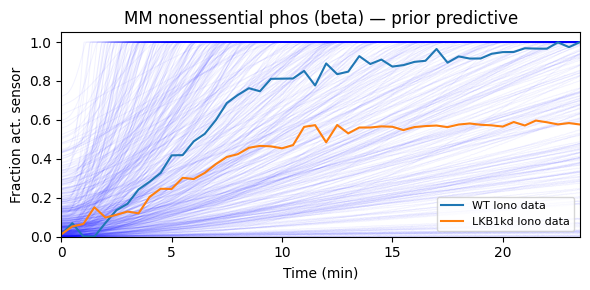

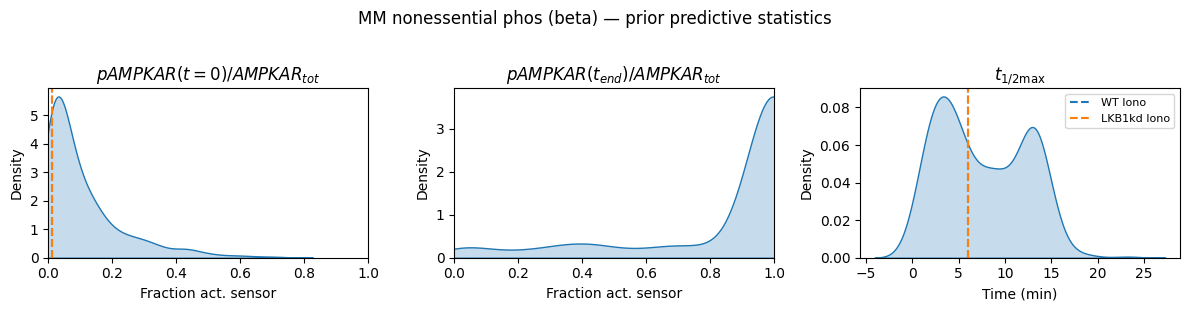

In [23]:
colors = {'wt': 'tab:blue', 'lkb1kd': 'tab:orange'}

def compute_half_max(arr):
    half_max = arr.max() / 2
    return jnp.argmin(jnp.abs(arr - half_max))

preds_MM_phos = np.squeeze(prior_pred_MM_phos.prior_predictive['like'].values[0])
if preds_MM_phos.ndim == 1:
    preds_MM_phos = preds_MM_phos[np.newaxis, :]

# --- Trajectories with both data traces overlaid ---
fig, ax = plt.subplots(figsize=(6, 3))
for i in range(preds_MM_phos.shape[0]):
    ax.plot(iono_times_fine / 60, preds_MM_phos[i], 'b', alpha=0.05, linewidth=0.75)
for key, ds in datasets.items():
    ax.plot(ds['times'], ds['data'].flatten(), markersize=3,
            color=colors[key], label=ds['label'] + ' data', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Fraction act. sensor')
ax.set_xlim([0, iono_times_fine.max() / 60])
ax.set_ylim([0, 1.05])
ax.set_title('MM nonessential phos (beta) — prior predictive')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MM_nonessential_phos.pdf', bbox_inches='tight')

# --- Density statistics ---
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3))

# Initial activation
sns.kdeplot(preds_MM_phos[:, 0], ax=axes2[0], fill=True, alpha=0.25)
for key, ds in datasets.items():
    axes2[0].axvline(ds['data'].flatten()[0], color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[0].set_xlabel('Fraction act. sensor')
axes2[0].set_title(r'$pAMPKAR(t=0) / AMPKAR_{tot}$')
axes2[0].set_xlim([0, 1])

# Final activation
sns.kdeplot(preds_MM_phos[:, -1], ax=axes2[1], fill=True, alpha=0.25)
axes2[1].set_xlabel('Fraction act. sensor')
axes2[1].set_title(r'$pAMPKAR(t_{end}) / AMPKAR_{tot}$')
axes2[1].set_xlim([0, 1])

# Time to half-max
t_halfs_idxs_MM_phos = jnp.apply_along_axis(compute_half_max, 1, preds_MM_phos)
t_halfs_MM_phos = [iono_times_fine[i] / 60 for i in t_halfs_idxs_MM_phos]
sns.kdeplot(t_halfs_MM_phos, ax=axes2[2], fill=True, alpha=0.25)
for key, ds in datasets.items():
    t_half_data = ds['times'][compute_half_max(ds['data'].flatten())]
    axes2[2].axvline(t_half_data, color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[2].set_xlabel('Time (min)')
axes2[2].set_title(r'$t_{1/2 \max}$')
axes2[2].legend(fontsize=8)

fig2.suptitle('MM nonessential phos (beta) — prior predictive statistics', y=1.02)
fig2.tight_layout()
fig2.savefig(savedir + 'prior_pred_MM_nonessential_phos_stats.pdf', bbox_inches='tight')

In [24]:
# Compute 95% HDI bounds and save updated MM nonessential phos model info
MM_phos_bounds_updated = {}
MM_phos_prior_params_updated = {}
for param in MM_phos_info['params']:
    if param in prior_params_MM_phos:
        MM_phos_bounds_updated[param] = list(
            pz.LogNormal(mu=prior_params_MM_phos[param]['mu'], sigma=prior_params_MM_phos[param]['sigma'])
            .hdi(0.95, fmt='.8f')
        )
        MM_phos_prior_params_updated[param] = prior_params_MM_phos[param]
    else:
        MM_phos_bounds_updated[param] = []
        MM_phos_prior_params_updated[param] = {}

MM_phos_info['param_bounds'] = MM_phos_bounds_updated
MM_phos_info['prior_params'] = MM_phos_prior_params_updated

with open('../models/MM_nonessential_phos.json', 'w') as f:
    json.dump(MM_phos_info, f, indent=4)
print('Saved updated model info to MM_nonessential_phos.json')

Saved updated model info to MM_nonessential_phos.json
